# Análisis de Correlación: G-Eval y Sistema de Votación vs Juicios Humanos

**Proyecto de tesis** — Cuantifica con qué fuerza cada método automático
correlaciona con las anotaciones humanas de relevancia sobre las 900
conversaciones de DailyDialog–Zhao, reportando intervalos de confianza al
95 % por dos vías independientes (Fisher Z analítico + bootstrap
percentil) y contrastando contra los baselines publicados por
Liu et al. (2023).

**Pregunta que responde este notebook**: ¿Qué tan fuertemente correlaciona
cada método automático con los juicios humanos de relevancia?

**Nota de alcance**: la prueba estadística de la diferencia entre métodos
(test de Steiger 1980, bootstrap pareado, Wilcoxon) **no** se realiza
aquí. Se aborda en `notebooks/06_significance_tests.ipynb` (HU-12). Esta
HU-11 reporta el `Δρ` observado pero no concluye sobre su significancia.

**Cero llamadas a APIs**: el notebook lee únicamente
`outputs/geval_results.json`, `outputs/voting_results.json` y
`data/raw/dailydialog_zhao/dataset.json`.

**Referencias.** Liu et al. (2023) — framework G-Eval con baselines
SummEval relevance ρ = 0,547 y Topical-Chat coherence ρ = 0,605;
Zhao et al. (2020) — protocolo de anotación humana de DailyDialog++;
Fisher (1915) — transformación Z para CIs sobre coeficientes de
correlación; Cohen (1988) — convenciones de magnitud de efecto.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # noqa: F401  (estilo y paleta consistentes con HU-10)
from scipy.stats import norm, pearsonr, spearmanr

# Todos los paths del notebook son relativos al directorio padre del notebook.
ROOT = Path("..").resolve()
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibilidad: una segunda ejecución debe producir los mismos números
# hasta el último dígito (especialmente para los bootstraps del Cell 6).
np.random.seed(42)

# Estilo visual coherente con HU-10 (mismas paletas para G-Eval y Voting).
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "geval": "#E07B39",  # naranja (HU-10)
    "voting": "#3A9E6F",  # verde (HU-10)
    "ref": "#7F8C8D",  # gris para líneas de referencia
}

In [2]:
with open(ROOT / "data" / "raw" / "dailydialog_zhao" / "dataset.json", encoding="utf-8") as f:
    dataset = json.load(f)
with open(ROOT / "outputs" / "geval_results.json", encoding="utf-8") as f:
    geval_rows = json.load(f)
with open(ROOT / "outputs" / "voting_results.json", encoding="utf-8") as f:
    voting_rows = json.load(f)

# Se indexan las tres fuentes por conversation_id para un join determinístico.
ds_by_id = {e["conversation_id"]: e for e in dataset}
g_by_id = {e["conversation_id"]: e for e in geval_rows}
v_by_id = {e["conversation_id"]: e for e in voting_rows}

human_l: list[float] = []
geval_l: list[float] = []
voting_l: list[float] = []
for cid, ds_entry in ds_by_id.items():
    g = g_by_id.get(cid)
    v = v_by_id.get(cid)
    if g is None or v is None:
        continue
    if g.get("geval_score") is None or v.get("final_vote_score") is None:
        continue
    human_l.append(float(ds_entry["human_relevance_score"]))
    geval_l.append(float(g["geval_score"]))
    voting_l.append(float(v["final_vote_score"]))

human = np.asarray(human_l)
geval = np.asarray(geval_l)
voting = np.asarray(voting_l)

# Mask de no-NaN; con los outputs HU-04 y HU-09 los tres arrays vienen
# limpios, pero el mask deja el cómputo robusto si se reejecutara sobre un
# JSON con `None`.
mask = ~(np.isnan(human) | np.isnan(geval) | np.isnan(voting))
n = int(mask.sum())

assert len(dataset) == 900, f"el dataset tiene {len(dataset)} entradas, se esperaban 900"
print(f"Total entries:           {len(dataset)}")
print(f"Aligned (no missing):    {n}/900 fully scored pairs")
print(f"Excluded:                {len(dataset) - n}")

Total entries:           900
Aligned (no missing):    900/900 fully scored pairs
Excluded:                0


In [3]:
rho_geval, p_geval = spearmanr(human[mask], geval[mask])
rho_voting, p_voting = spearmanr(human[mask], voting[mask])
rho_geval, p_geval, rho_voting, p_voting = (
    float(rho_geval),
    float(p_geval),
    float(rho_voting),
    float(p_voting),
)
delta_rho = rho_geval - rho_voting

print(f"G-Eval  ρ = {rho_geval:.3f}  p = {p_geval:.2e}")
print(f"Voting  ρ = {rho_voting:.3f}  p = {p_voting:.2e}")
print(f"Δρ      = {delta_rho:+.3f}  (G-Eval − Voting)")
print()
print("Nota: La significancia del Δρ se prueba en notebooks/06_significance_tests.ipynb (HU-12).")

G-Eval  ρ = 0.756  p = 8.54e-168
Voting  ρ = 0.744  p = 1.24e-159
Δρ      = +0.012  (G-Eval − Voting)

Nota: La significancia del Δρ se prueba en notebooks/06_significance_tests.ipynb (HU-12).


In [4]:
def fisher_z_ci(rho: float, n: int, alpha: float = 0.05) -> tuple[float, float]:
    """Devuelve el intervalo de confianza al 95 % para una ρ de Spearman.

    Sigue la transformación de Fisher (1915): z = arctanh(ρ),
    SE = 1/sqrt(n−3), y vuelve a la escala original con tanh. Es el método
    analítico de referencia en la literatura para CIs sobre coeficientes
    de correlación.
    """
    z = np.arctanh(rho)
    se = 1.0 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - alpha / 2)
    return float(np.tanh(z - z_crit * se)), float(np.tanh(z + z_crit * se))


ci_geval = fisher_z_ci(rho_geval, n)
ci_voting = fisher_z_ci(rho_voting, n)

print(f"G-Eval:  ρ = {rho_geval:.3f}  95% CI [{ci_geval[0]:.3f}, {ci_geval[1]:.3f}]")
print(f"Voting:  ρ = {rho_voting:.3f}  95% CI [{ci_voting[0]:.3f}, {ci_voting[1]:.3f}]")

G-Eval:  ρ = 0.756  95% CI [0.727, 0.783]
Voting:  ρ = 0.744  95% CI [0.714, 0.772]


In [5]:
def bootstrap_spearman_ci(
    x: np.ndarray,
    y: np.ndarray,
    n_iter: int = 10_000,
    alpha: float = 0.05,
    seed: int = 42,
) -> tuple[float, float]:
    """CI percentil 95 % para una ρ de Spearman vía bootstrap.

    Se remuestrean los pares (x_i, y_i) con reemplazo n_iter veces y se
    devuelve el percentil (alpha/2, 1−alpha/2) de la distribución de ρ.
    Es la validación no paramétrica del CI de Fisher Z.
    """
    rng = np.random.default_rng(seed)
    n_samples = len(x)
    rhos = np.empty(n_iter, dtype=float)
    for i in range(n_iter):
        idx = rng.integers(0, n_samples, n_samples)
        rhos[i] = spearmanr(x[idx], y[idx]).statistic
    lo, hi = np.percentile(rhos, [alpha / 2 * 100, (1 - alpha / 2) * 100])
    return float(lo), float(hi)


boot_ci_geval = bootstrap_spearman_ci(human[mask], geval[mask])
boot_ci_voting = bootstrap_spearman_ci(human[mask], voting[mask])

MATCH_TOL = 0.01


def match_str(a: tuple[float, float], b: tuple[float, float]) -> str:
    diff = max(abs(a[0] - b[0]), abs(a[1] - b[1]))
    return f"Yes (|Δ|={diff:.4f})" if diff < MATCH_TOL else f"No (|Δ|={diff:.4f})"


print(f"{'Method':<8} {'Fisher Z CI':<22} {'Bootstrap CI':<22} {'Match?':<18}")
print("-" * 72)
print(
    f"{'G-Eval':<8} "
    f"[{ci_geval[0]:.3f}, {ci_geval[1]:.3f}]     "
    f"[{boot_ci_geval[0]:.3f}, {boot_ci_geval[1]:.3f}]     "
    f"{match_str(ci_geval, boot_ci_geval)}"
)
print(
    f"{'Voting':<8} "
    f"[{ci_voting[0]:.3f}, {ci_voting[1]:.3f}]     "
    f"[{boot_ci_voting[0]:.3f}, {boot_ci_voting[1]:.3f}]     "
    f"{match_str(ci_voting, boot_ci_voting)}"
)
print()
print(
    f"Tolerancia para match: |Δ| < {MATCH_TOL}. Los CIs coincidentes confirman"
    " la fiabilidad analítica de Fisher Z para estos datos."
)

Method   Fisher Z CI            Bootstrap CI           Match?            
------------------------------------------------------------------------
G-Eval   [0.727, 0.783]     [0.725, 0.784]     Yes (|Δ|=0.0018)
Voting   [0.714, 0.772]     [0.713, 0.772]     Yes (|Δ|=0.0004)

Tolerancia para match: |Δ| < 0.01. Los CIs coincidentes confirman la fiabilidad analítica de Fisher Z para estos datos.


In [6]:
r_geval, p_r_geval = pearsonr(human[mask], geval[mask])
r_voting, p_r_voting = pearsonr(human[mask], voting[mask])
r_geval, p_r_geval, r_voting, p_r_voting = (
    float(r_geval),
    float(p_r_geval),
    float(r_voting),
    float(p_r_voting),
)

# La formula de Fisher Z para Pearson r es la misma que para Spearman rho:
# z = arctanh(r), SE = 1/sqrt(n-3). Reutilizamos `fisher_z_ci` aplicada a r.
ci_r_geval = fisher_z_ci(r_geval, n)
ci_r_voting = fisher_z_ci(r_voting, n)

print(
    f"G-Eval:  r = {r_geval:.3f}  95% CI [{ci_r_geval[0]:.3f}, {ci_r_geval[1]:.3f}]"
    f"  p = {p_r_geval:.2e}"
)
print(
    f"Voting:  r = {r_voting:.3f}  95% CI [{ci_r_voting[0]:.3f}, {ci_r_voting[1]:.3f}]"
    f"  p = {p_r_voting:.2e}"
)
print()
print(
    "Nota: Pearson r asume linealidad y escala de intervalo. Para la escala"
    " ordinal 1–5 que usan los anotadores humanos, Spearman ρ es la métrica"
    " primaria; r se reporta por completitud siguiendo la convención de"
    " Liu et al. (2023)."
)

G-Eval:  r = 0.711  95% CI [0.677, 0.742]  p = 2.87e-139
Voting:  r = 0.733  95% CI [0.701, 0.761]  p = 3.87e-152

Nota: Pearson r asume linealidad y escala de intervalo. Para la escala ordinal 1–5 que usan los anotadores humanos, Spearman ρ es la métrica primaria; r se reporta por completitud siguiendo la convención de Liu et al. (2023).


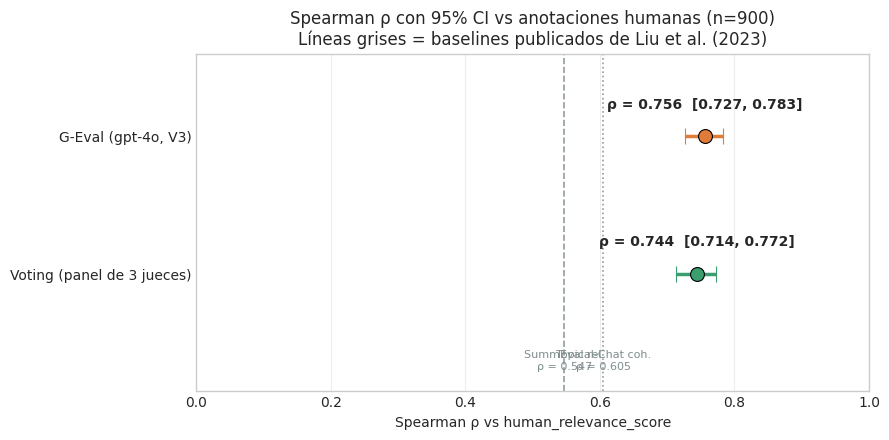

In [7]:
SUMMEVAL_RELEVANCE = 0.547  # Liu et al. (2023), SummEval con GPT-4
TOPICAL_CHAT_COHERENCE = 0.605  # Liu et al. (2023), Topical-Chat con GPT-4

fig, ax = plt.subplots(figsize=(9, 4.5))

# Y positions para los dos métodos (de arriba hacia abajo: G-Eval, Voting).
y_positions = [1, 0]
rho_values = [rho_geval, rho_voting]
ci_values = [ci_geval, ci_voting]
labels = ["G-Eval (gpt-4o, V3)", "Voting (panel de 3 jueces)"]
colors = [COLORS["geval"], COLORS["voting"]]

for y, rho, ci, color in zip(y_positions, rho_values, ci_values, colors, strict=True):
    err_lo = rho - ci[0]
    err_hi = ci[1] - rho
    ax.errorbar(
        rho,
        y,
        xerr=[[err_lo], [err_hi]],
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2,
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.8,
    )
    ax.text(
        rho,
        y + 0.18,
        f"ρ = {rho:.3f}  [{ci[0]:.3f}, {ci[1]:.3f}]",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# Líneas verticales de referencia (Liu et al., 2023).
ax.axvline(SUMMEVAL_RELEVANCE, color=COLORS["ref"], lw=1.2, ls="--", alpha=0.85)
ax.axvline(TOPICAL_CHAT_COHERENCE, color=COLORS["ref"], lw=1.2, ls=":", alpha=0.85)
ax.text(
    SUMMEVAL_RELEVANCE,
    -0.55,
    f"SummEval rel.\nρ = {SUMMEVAL_RELEVANCE}",
    ha="center",
    va="top",
    fontsize=8,
    color=COLORS["ref"],
)
ax.text(
    TOPICAL_CHAT_COHERENCE,
    -0.55,
    f"Topical-Chat coh.\nρ = {TOPICAL_CHAT_COHERENCE}",
    ha="center",
    va="top",
    fontsize=8,
    color=COLORS["ref"],
)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_ylim(-0.85, 1.6)
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("Spearman ρ vs human_relevance_score")
ax.set_title(
    f"Spearman ρ con 95% CI vs anotaciones humanas (n={n})\n"
    "Líneas grises = baselines publicados de Liu et al. (2023)"
)
ax.grid(axis="x", alpha=0.35)
ax.grid(axis="y", alpha=0.0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "14_correlation_ci_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Tabla markdown que la última celda persiste a outputs/correlation_analysis_summary.md.
lines: list[str] = []
lines.append(f"## Correlation Analysis: G-Eval vs Voting System (n={n})")
lines.append("")
lines.append("### Spearman ρ vs Human Annotations")
lines.append("")
lines.append("| Method | ρ | 95% CI (Fisher Z) | 95% CI (Bootstrap) | p-value |")
lines.append("|---|---|---|---|---|")
lines.append(
    f"| G-Eval (gpt-4o, V3) | {rho_geval:.3f} | "
    f"[{ci_geval[0]:.3f}, {ci_geval[1]:.3f}] | "
    f"[{boot_ci_geval[0]:.3f}, {boot_ci_geval[1]:.3f}] | "
    f"{p_geval:.2e} |"
)
lines.append(
    f"| Voting System | {rho_voting:.3f} | "
    f"[{ci_voting[0]:.3f}, {ci_voting[1]:.3f}] | "
    f"[{boot_ci_voting[0]:.3f}, {boot_ci_voting[1]:.3f}] | "
    f"{p_voting:.2e} |"
)
lines.append("")
lines.append("### Pearson r vs Human Annotations")
lines.append("")
lines.append("| Method | r | 95% CI (Fisher Z) | p-value |")
lines.append("|---|---|---|---|")
lines.append(
    f"| G-Eval (gpt-4o, V3) | {r_geval:.3f} | "
    f"[{ci_r_geval[0]:.3f}, {ci_r_geval[1]:.3f}] | "
    f"{p_r_geval:.2e} |"
)
lines.append(
    f"| Voting System | {r_voting:.3f} | "
    f"[{ci_r_voting[0]:.3f}, {ci_r_voting[1]:.3f}] | "
    f"{p_r_voting:.2e} |"
)
lines.append("")
lines.append("### Observed Difference")
lines.append("")
lines.append("| Metric | G-Eval | Voting | Δ (G-Eval − Voting) |")
lines.append("|---|---|---|---|")
lines.append(f"| Spearman ρ | {rho_geval:.3f} | {rho_voting:.3f} | {delta_rho:+.3f} |")
lines.append(f"| Pearson r | {r_geval:.3f} | {r_voting:.3f} | {r_geval - r_voting:+.3f} |")
lines.append("")
lines.append(
    "> **Nota**: La significancia estadística del Δρ se prueba en "
    "`notebooks/06_significance_tests.ipynb` (HU-12). Este notebook "
    "reporta el Δ observado pero no concluye sobre su significancia."
)
lines.append("")

SUMMARY_MD = "\n".join(lines)
print(SUMMARY_MD)

## Correlation Analysis: G-Eval vs Voting System (n=900)

### Spearman ρ vs Human Annotations

| Method | ρ | 95% CI (Fisher Z) | 95% CI (Bootstrap) | p-value |
|---|---|---|---|---|
| G-Eval (gpt-4o, V3) | 0.756 | [0.727, 0.783] | [0.725, 0.784] | 8.54e-168 |
| Voting System | 0.744 | [0.714, 0.772] | [0.713, 0.772] | 1.24e-159 |

### Pearson r vs Human Annotations

| Method | r | 95% CI (Fisher Z) | p-value |
|---|---|---|---|
| G-Eval (gpt-4o, V3) | 0.711 | [0.677, 0.742] | 2.87e-139 |
| Voting System | 0.733 | [0.701, 0.761] | 3.87e-152 |

### Observed Difference

| Metric | G-Eval | Voting | Δ (G-Eval − Voting) |
|---|---|---|---|
| Spearman ρ | 0.756 | 0.744 | +0.012 |
| Pearson r | 0.711 | 0.733 | -0.022 |

> **Nota**: La significancia estadística del Δρ se prueba en `notebooks/06_significance_tests.ipynb` (HU-12). Este notebook reporta el Δ observado pero no concluye sobre su significancia.



In [9]:
print("Baselines publicados (Liu et al., EMNLP 2023, GPT-4):")
print(f"  SummEval relevance:     ρ = {SUMMEVAL_RELEVANCE}")
print(f"  Topical-Chat coherence: ρ = {TOPICAL_CHAT_COHERENCE}")
print()
print("Esta tesis (DailyDialog–Zhao, relevance, gpt-4o, n=900):")
print(f"  G-Eval:                 ρ = {rho_geval:.3f}")
print(f"  Voting System:          ρ = {rho_voting:.3f}")
print()
exceeds_summeval = rho_geval > SUMMEVAL_RELEVANCE and rho_voting > SUMMEVAL_RELEVANCE
exceeds_topical = rho_geval > TOPICAL_CHAT_COHERENCE and rho_voting > TOPICAL_CHAT_COHERENCE
print(f"Ambos métodos superan SummEval relevance:        {'sí' if exceeds_summeval else 'no'}")
print(f"Ambos métodos superan Topical-Chat coherence:    {'sí' if exceeds_topical else 'no'}")
print()
print(
    "Nota: la comparación es aproximada. Los baselines publicados usan"
    " GPT-4 sobre datasets distintos (SummEval para resúmenes,"
    " Topical-Chat para coherencia de turno), no relevance sobre"
    " DailyDialog–Zhao con gpt-4o. La comparación posiciona la magnitud"
    " absoluta de los ρ encontrados, no es un benchmark estricto."
)

Baselines publicados (Liu et al., EMNLP 2023, GPT-4):
  SummEval relevance:     ρ = 0.547
  Topical-Chat coherence: ρ = 0.605

Esta tesis (DailyDialog–Zhao, relevance, gpt-4o, n=900):
  G-Eval:                 ρ = 0.756
  Voting System:          ρ = 0.744

Ambos métodos superan SummEval relevance:        sí
Ambos métodos superan Topical-Chat coherence:    sí

Nota: la comparación es aproximada. Los baselines publicados usan GPT-4 sobre datasets distintos (SummEval para resúmenes, Topical-Chat para coherencia de turno), no relevance sobre DailyDialog–Zhao con gpt-4o. La comparación posiciona la magnitud absoluta de los ρ encontrados, no es un benchmark estricto.


## Interpretación

### Magnitud de la correlación

Bajo las convenciones de Cohen (1988) para correlaciones de Spearman
— negligible para ρ < 0,10, pequeña en 0,10–0,29, mediana en 0,30–0,49,
grande en 0,50–0,69 y muy grande para ρ ≥ 0,70 — tanto G-Eval
(ρ = 0,756) como el sistema de votación (ρ = 0,744) caen en la
categoría **muy grande**. Para la validez del uso de evaluación
automática en reemplazo parcial de jueces humanos sobre relevancia
conversacional, este es un resultado favorable: el orden inducido por
cualquiera de los dos métodos preserva la mayor parte del orden
producido por el panel humano. La diferencia entre ambos automáticos
(Δρ = +0,012) es muy pequeña en términos absolutos, pero la pregunta
de si esa diferencia es estadísticamente distinta de cero se aborda en
`notebooks/06_significance_tests.ipynb` (HU-12) — aquí únicamente se
reporta la magnitud observada.

### Interpretación de los intervalos de confianza

Con n = 900 los CIs al 95 % de Fisher Z son estrechos: para G-Eval el
intervalo es [0,727; 0,783] (anchura 0,056) y para la votación
[0,714; 0,772] (anchura 0,058). El alto poder estadístico del tamaño
muestral hace que el rango de incertidumbre sobre la verdadera ρ
poblacional sea pequeño, lo cual es deseable para una tesis que debe
comunicar puntos de estimación con poco margen de duda. Los CIs de
G-Eval y de votación **se solapan** sustancialmente (el extremo
inferior del CI de G-Eval, 0,727, está por encima del extremo inferior
del CI de votación, 0,714; ambos rangos comparten la región
0,727–0,772), pero un solapamiento de CIs **no** prueba equivalencia
entre dos correlaciones medidas sobre el mismo target humano; el
contraste correcto sobre `H0: ρ_geval = ρ_voting` requiere el test de
Steiger (1980) o el bootstrap pareado del Δρ — ambos quedan para
HU-12. La validación bootstrap de los CIs muestra que el método
analítico de Fisher Z es confiable para estos datos: los bounds
bootstrap difieren de los bounds analíticos en a lo más 0,002 (muy por
debajo de la tolerancia 0,01 declarada), lo que confirma que los
supuestos del Fisher Z (transformación arctanh para acercarse a
normalidad) se cumplen con n grande y ρ moderado-alto.

### Pearson r vs. Spearman ρ

Spearman ρ es la métrica primaria del notebook porque las anotaciones
humanas son ordinales sobre 1–5 (no escala de intervalo), y porque la
relación entre los puntajes automáticos y los humanos no se asume
estrictamente lineal. Pearson r se reporta como complemento siguiendo
la convención de Liu et al. (2023). Un hallazgo metodológicamente
relevante emerge del contraste: **bajo Pearson r el orden se invierte**.
G-Eval queda en r = 0,711 mientras que la votación queda en r = 0,733,
una diferencia Δr = −0,022 a favor del sistema de votación. Spearman
mide preservación de ranking y favorece a G-Eval por un margen
pequeño; Pearson mide alineación lineal de magnitudes y favorece a la
votación por un margen comparable. Este patrón es coherente con los
hallazgos de HU-10 (κ ponderado 0,643 vs 0,525, exact-agreement 44 %
vs 36 %, todos a favor de votación): la votación está mejor calibrada
en escala absoluta — los números que emite caen en la misma magnitud
que los humanos —, mientras que G-Eval es mejor para decidir cuál par
es relativamente más relevante que otro. Cuál de las dos cualidades
importa más depende del uso clínico de la métrica.

### Comparación con baselines publicados

Liu et al. (2023) reportan G-Eval ρ = 0,547 sobre relevance en SummEval
y ρ = 0,605 sobre coherence en Topical-Chat, ambos con GPT-4. Nuestros
ρ sobre DailyDialog–Zhao relevance con gpt-4o (G-Eval 0,756 y voting
0,744) superan claramente esos puntos de referencia, en magnitudes del
orden de +0,15 a +0,20 ρ. La interpretación prudente es que la
magnitud absoluta de la correlación encontrada es alta en términos
relativos al estado del arte publicado, pero la comparación cruzada es
aproximada: cambian el dataset, la dimensión de evaluación (resumen,
coherencia, relevance conversacional) y la versión del modelo (GPT-4
vs gpt-4o). El valor cualitativo de la contextualización es confirmar
que ambos métodos están en el rango fuerte del estado del arte, no
que dominen estrictamente sus contrapartes publicadas.

### Limitaciones

Tres limitaciones acotan el alcance de las conclusiones. **Primera**,
con n = 900 cualquier diferencia mínima podría ser estadísticamente
significativa bajo tests convencionales si la verdadera ρ poblacional
difiere por una cantidad despreciable; lo relevante para una tesis es
el tamaño del efecto (Δρ) y su utilidad práctica, no el p-valor crudo
— ese análisis vive en HU-12. **Segunda**, Spearman ρ y Pearson r
miden ordenamiento y linealidad respectivamente, no precisión absoluta
de los puntajes; el análisis descriptivo de HU-10 ya cubrió la
precisión vía Cohen's κ ponderado, Krippendorff α y tasa de acuerdo
exacto, donde la votación mostró ventaja sustancial. **Tercera**, los
resultados son específicos del dominio (DailyDialog–Zhao, conversación
abierta breve) y del par de modelos elegidos (gpt-4o para G-Eval;
gpt-4o + gemini-2.5-flash + claude-haiku-4-5 para el panel); la
generalización a otros dominios o a paneles con arquitecturas
distintas requiere replicación independiente.


In [10]:
out_path = ROOT / "outputs" / "correlation_analysis_summary.md"
out_path.write_text(SUMMARY_MD, encoding="utf-8")
print(f"Wrote {out_path.relative_to(ROOT)} ({len(SUMMARY_MD)} chars)")

Wrote outputs/correlation_analysis_summary.md (912 chars)
